<a href="https://colab.research.google.com/github/vasanthjilla089-cmd/blog/blob/main/_vasanthakumar_Bank_Marketing_%26_Customer_Behavior_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Project title  :

Bank Term Deposit Subscription Prediction Using Machine Learning


## Problem statement

To predict whether a bank customer will subscribe to a term deposit based on customer and campaign data using machine learning.


## **STAGE-1**  

Dateset selection with Initial EDA



```
# This is formatted as code
```

UCI Machine Learning Repository – Bank Marketing Dataset

Timeline-

2014 (Dataset Published)

Location-

Portuguese Banking Institution (Portugal)

## Type of Problem

Classification

 ## Regression / Classification

Binary Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import zipfile
import os

# Define paths for the main zip file and its extraction directory
main_zip_path = '/content/bank+marketing (2).zip'
main_extract_dir = '/content/extracted_main_zip'

# Create the extraction directory for the main zip if it doesn't exist
os.makedirs(main_extract_dir, exist_ok=True)

# Extract the main zip file
print(f"Extracting '{main_zip_path}' to '{main_extract_dir}'...")
with zipfile.ZipFile(main_zip_path, 'r') as zip_ref:
    zip_ref.extractall(main_extract_dir)
print("Main zip extraction complete.")

# Define paths for the nested 'bank.zip' and its extraction directory
bank_zip_path = os.path.join(main_extract_dir, 'bank.zip')
bank_data_extract_dir = os.path.join(main_extract_dir, 'bank_data') # Changed this line to a new directory

# Create the extraction directory for 'bank.zip' if it doesn't exist
os.makedirs(bank_data_extract_dir, exist_ok=True)

# Extract the 'bank.zip' file
print(f"Extracting '{bank_zip_path}' to '{bank_data_extract_dir}'...")
with zipfile.ZipFile(bank_zip_path, 'r') as zip_ref:
    zip_ref.extractall(bank_data_extract_dir)
print("'bank.zip' extraction complete.")

# Now, read the 'bank-full.csv' from the final extracted location
csv_file_path = os.path.join(bank_data_extract_dir, 'bank-full.csv')

print(f"Loading data from '{csv_file_path}'...")
df = pd.read_csv(csv_file_path, sep=';') # Assuming semicolon delimiter common in bank datasets

print("DataFrame loaded successfully. Displaying the first 5 rows:")
print(df.head())

Extracting '/content/bank+marketing (2).zip' to '/content/extracted_main_zip'...
Main zip extraction complete.
Extracting '/content/extracted_main_zip/bank.zip' to '/content/extracted_main_zip/bank_data'...
'bank.zip' extraction complete.
Loading data from '/content/extracted_main_zip/bank_data/bank-full.csv'...
DataFrame loaded successfully. Displaying the first 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151  

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,5.568345,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,5.023881,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,4.343805,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,4.532599,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,5.293305,1,-1,0,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
print(df.isnull().sum())


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
df.count().sum()

np.int64(768587)

### Shape

In [ ]:
df.shape

(45211, 17)

In [ ]:
print(df["y"].unique())

['no' 'yes']


In [ ]:
print(df["y"].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


## Describing the Dataset
Dataset Name: Bank Marketing Dataset
Source: UCI Machine Learning Repository
Total Records: 45,211
Total Features: 16 Input Features + 1 Target Variable (y)
Target Variable: y (Term Deposit Subscription: Yes / No)

### Finding the duplicates


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Display the duplicate rows if any exist
if df.duplicated().sum() > 0:
    print("Duplicate rows (first 5):")
    print(df[df.duplicated()].head())

Number of duplicate rows: 0


### Finding the null values

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Target Feature
y – Term Deposit (Yes/No)
## Input Features
age
job
marital
education
default
balance
housing
loan
contact
day
month
duration
campaign
pdays
previous
poutcome

## Sample Output
y

## Information about the Dataset
Records: 45,211
Features: 16
Target: y (Yes/No)
Type: Binary Classification
Source: UCI Machine Learning Repository

## Stage 2: Data Preprocessing
Data Cleaning
Handling Missing Values
Removing Duplicates
Encoding Categorical Features
Feature and Target Selection
Train-Test Split
Feature Scaling (if required)

In [ ]:
missing_values = df.isna().sum()
print(missing_values)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


# Check duplicate records


In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [ ]:
df = df.loc[~df.duplicated()]

In [ ]:
print("Duplicates After Cleaning:", df.duplicated().sum())

Duplicates After Cleaning: 0


# Select numerical columns


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
print(num_cols.skew())

In [ ]:
print(num_cols.skew())

age          0.684818
balance      8.360308
day          0.093079
duration     3.144318
campaign     4.898650
pdays        2.615715
previous    41.846454
dtype: float64


In [ ]:
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR))).sum()
print(outliers)

# This is formatted as code

### Handling skewness

In [ ]:
 print(df.skew(numeric_only=True))

age          0.684818
balance      8.360308
day          0.093079
duration     3.144318
campaign     4.898650
pdays        2.615715
previous    41.846454
dtype: float64


In [ ]:
import numpy as np

df["balance"] = np.log1p(df["balance"])
df["duration"] = np.log1p(df["duration"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
print(df[["balance", "duration"]].skew())

balance          NaN
duration   -0.454164
dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,4.149500e+04,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,-inf,15.806419,5.171812,2.763841,40.197828,0.580323
std,10.618762,NaN,8.322476,0.921822,3.098021,100.128746,2.303441
min,18.000000,-inf,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,4.983607e+00,8.000000,4.644391,1.000000,-1.000000,0.000000
50%,39.000000,6.295266e+00,16.000000,5.198497,2.000000,-1.000000,0.000000
75%,48.000000,7.374629e+00,21.000000,5.768321,3.000000,-1.000000,0.000000
max,95.000000,1.153398e+01,31.000000,8.500861,63.000000,871.000000,275.000000


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other  

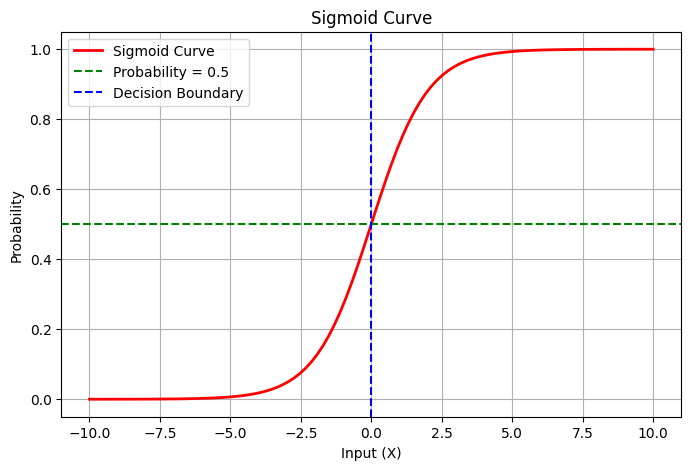

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# X values
x = np.linspace(-10, 10, 100)

# Sigmoid function
y = 1 / (1 + np.exp(-x))

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, y, color='red', linewidth=2, label='Sigmoid Curve')
plt.axhline(y=0.5, color='green', linestyle='--', label='Probability = 0.5')
plt.axvline(x=0, color='blue', linestyle='--', label='Decision Boundary')

plt.title("Sigmoid Curve")
plt.xlabel("Input (X)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
for  col in df.select_dtypes(include ='object').columns:
    print(df[col].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other  

# Target variable distribution


In [ ]:
df.corr(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.065206,-0.009120,-0.003575,0.004760,-0.023758,0.001288
balance,0.065206,1.000000,-0.003672,0.044001,-0.042037,0.046268,0.042288
day,-0.009120,-0.003672,1.000000,-0.056959,0.162490,-0.093044,-0.051710
duration,-0.003575,0.044001,-0.056959,1.000000,-0.209043,0.005198,-0.001148
campaign,0.004760,-0.042037,0.162490,-0.209043,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.046268,-0.093044,0.005198,-0.088628,1.000000,0.454820
previous,0.001288,0.042288,-0.051710,-0.001148,-0.032855,0.454820,1.000000


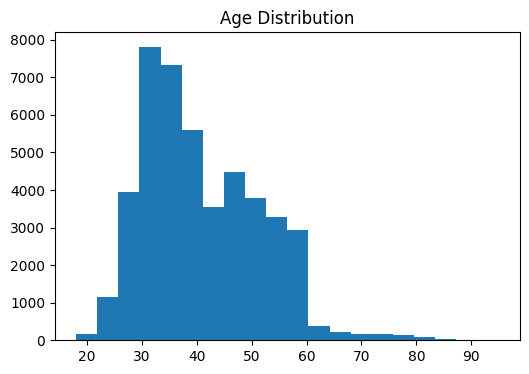

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

In [ ]:
pd.crosstab(df["job"], df["y"])

y,no,yes
job,,
admin.,4540,631
blue-collar,9024,708
entrepreneur,1364,123
housemaid,1131,109
management,8157,1301
retired,1748,516
self-employed,1392,187
services,3785,369
student,669,269


In [ ]:
X = df.drop("y", axis=1)
y = df["y"]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Re-load df from the original CSV to ensure a clean state for this cell.
# This prevents issues from previous in-place modifications to df.
csv_file_path = '/content/extracted_main_zip/bank_data/bank-full.csv' # Corrected this path
df = pd.read_csv(csv_file_path, sep=';')

# Apply log1p transformation only to 'duration' as it's typically non-negative and helps with skewness.
# 'balance' can contain negative values, so np.log1p is not suitable for it and caused the ValueError.
df["duration"] = np.log1p(df["duration"])

# Separate features (X) and target (y) variables
X = df.drop("y", axis=1)
y = df["y"]

# Identify categorical and numerical columns in X
numerical_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='object').columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that first preprocesses and then trains a Logistic Regression model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(solver='liblinear', random_state=42))])

# Convert target variable 'y' to numerical (0 for 'no', 1 for 'yes')
y_encoded = y.map({'no': 0, 'yes': 1})

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Train the model
model.fit(X_train, y_train)

# Extract coefficients and intercept from the trained Logistic Regression model
# For binary classification, coef_ is typically shape (1, n_features) and intercept_ is (1,)
model_coffiecient = model.named_steps['classifier'].coef_
model_intercept = model.named_steps['classifier'].intercept_

m = model_coffiecient[0][0]
c = model_intercept[0]

print(f"First coefficient (m): {m}")
print(f"Intercept (c): {c}")

First coefficient (m): -0.015285645322199065
Intercept (c): -0.644366239869819


In [ ]:
X_values = np.linspace(X['age'].min(), X['age'].max(), 300).reshape(-1,1)

In [ ]:
X_values

array([[18.        ],
       [18.25752508],
       [18.51505017],
       [18.77257525],
       [19.03010033],
       [19.28762542],
       [19.5451505 ],
       [19.80267559],
       [20.06020067],
       [20.31772575],
       [20.57525084],
       [20.83277592],
       [21.090301  ],
       [21.34782609],
       [21.60535117],
       [21.86287625],
       [22.12040134],
       [22.37792642],
       [22.63545151],
       [22.89297659],
       [23.15050167],
       [23.40802676],
       [23.66555184],
       [23.92307692],
       [24.18060201],
       [24.43812709],
       [24.69565217],
       [24.95317726],
       [25.21070234],
       [25.46822742],
       [25.72575251],
       [25.98327759],
       [26.24080268],
       [26.49832776],
       [26.75585284],
       [27.01337793],
       [27.27090301],
       [27.52842809],
       [27.78595318],
       [28.04347826],
       [28.30100334],
       [28.55852843],
       [28.81605351],
       [29.0735786 ],
       [29.33110368],
       [29

In [ ]:
def sigmoid(y):
    return 1 / (1 + np.exp(-y))

In [ ]:
y_sigmoid = sigmoid(y_encoded)

## **Stage 3**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Identify categorical and numerical columns from X_train
numerical_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit and transform X_train, and transform X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# The y_train and y_test are currently string labels due to prior train_test_split
# We need to explicitly convert them to numerical (0/1) for consistent model training and evaluation
y_train_encoded = y_train.map({'no': 0, 'yes': 1})
y_test_encoded = y_test.map({'no': 0, 'yes': 1})

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_processed, y_train_encoded)
    print(name, "Model Trained Successfully")

Logistic Regression Model Trained Successfully
Decision Tree Model Trained Successfully
Random Forest Model Trained Successfully


#### Defining features

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Use the preprocessed data (X_train_processed and y_train_encoded)
# which were created in the previous cell 'DoKLrtdMViH6'
model.fit(X_train_processed, y_train_encoded)

LogisticRegression()

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36168, 16)
(9043, 16)
(36168,)
(9043,)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_processed, y_train_encoded)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed, y_train_encoded)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train_encoded)

RandomForestClassifier(random_state=42)

## **Stage 4**

## Stage 4: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd # Import pandas for Series.map if needed

# Dictionary to store evaluation results
results = {}

# Evaluate Logistic Regression
y_pred_lr = lr.predict(X_test_processed)
# Ensure predictions are numerical (0 or 1) if they are currently strings ('no'/'yes')
if y_pred_lr.dtype == 'object':
    y_pred_lr = pd.Series(y_pred_lr).map({'no': 0, 'yes': 1}).values

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test_encoded, y_pred_lr),
    'Precision': precision_score(y_test_encoded, y_pred_lr, pos_label=1),
    'Recall': recall_score(y_test_encoded, y_pred_lr, pos_label=1),
    'F1-Score': f1_score(y_test_encoded, y_pred_lr, pos_label=1)
}

# Evaluate Decision Tree
y_pred_dt = dt.predict(X_test_processed)
if y_pred_dt.dtype == 'object':
    y_pred_dt = pd.Series(y_pred_dt).map({'no': 0, 'yes': 1}).values
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test_encoded, y_pred_dt),
    'Precision': precision_score(y_test_encoded, y_pred_dt, pos_label=1),
    'Recall': recall_score(y_test_encoded, y_pred_dt, pos_label=1),
    'F1-Score': f1_score(y_test_encoded, y_pred_dt, pos_label=1)
}

# Evaluate Random Forest
y_pred_rf = rf.predict(X_test_processed)
if y_pred_rf.dtype == 'object':
    y_pred_rf = pd.Series(y_pred_rf).map({'no': 0, 'yes': 1}).values
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test_encoded, y_pred_rf),
    'Precision': precision_score(y_test_encoded, y_pred_rf, pos_label=1),
    'Recall': recall_score(y_test_encoded, y_pred_rf, pos_label=1),
    'F1-Score': f1_score(y_test_encoded, y_pred_rf, pos_label=1)
}

# Print results in a readable format
print("Model Evaluation Results:")
for model_name, metrics in results.items():
    print(f"\n--- {model_name} ---")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

Model Evaluation Results:

--- Logistic Regression ---
Accuracy: 0.9011
Precision: 0.6707
Recall: 0.3547
F1-Score: 0.4640

--- Decision Tree ---
Accuracy: 0.8732
Precision: 0.4751
Recall: 0.4904
F1-Score: 0.4826

--- Random Forest ---
Accuracy: 0.9058
Precision: 0.6786
Recall: 0.4161
F1-Score: 0.5159


In [ ]:
y_pred = rf.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test_encoded, y_pred_lr)

0.9011390025434037

In [ ]:
model = LogisticRegression()

# Use the preprocessed data for training
model.fit(X_train_processed, y_train_encoded)

LogisticRegression()

In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test_encoded, y_pred_lr),
    "Decision Tree": accuracy_score(y_test_encoded, y_pred_dt),
    "Random Forest": accuracy_score(y_test_encoded, y_pred_rf)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9011
Decision Tree: 0.8732
Random Forest: 0.9058


##Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)
cm

array([[7737,  215],
       [ 637,  454]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.68      0.42      0.52      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



### GridSearchCV hyperparameter tuning

1.   List item
2.   List item



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2']
}

# Initialize the Logistic Regression model. Using parameters from previous runs.
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Initialize GridSearchCV
# cv=3 for cross-validation, scoring='accuracy' to evaluate the models, n_jobs=-1 to use all available processors
grid = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid.fit(X_train_processed, y_train_encoded)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1.0, 'penalty': 'l1'}
Best Score: 0.9035611590356116


In [ ]:
model = LogisticRegression()

model.fit(X_train_processed, y_train_encoded)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
accuracy_score(y_test_encoded,y_pred)

0.9011390025434037

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_encoded,y_pred)

array([[7737,  215],
       [ 637,  454]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_encoded,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.68      0.42      0.52      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



In [ ]:
import numpy as np
np.array(['no', 'yes'], dtype=object)

array(['no', 'yes'], dtype=object)

In [ ]:
df['y'].value_counts()

,count
y,
0,39922
1,5289


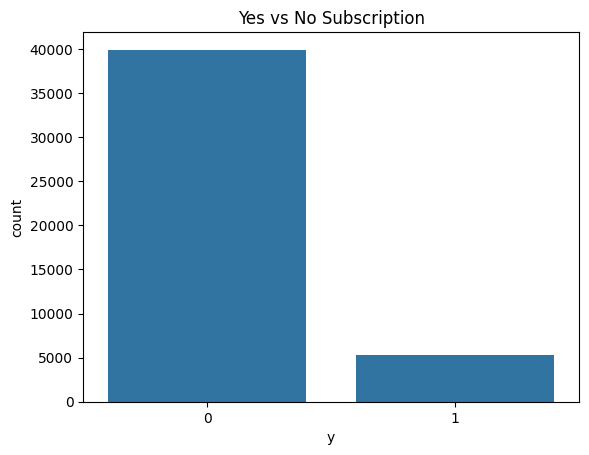

In [ ]:
sns.countplot(data=df, x='y')
plt.title("Yes vs No Subscription")
plt.show()

In [ ]:
probability = float(input("Enter Probability: "))

if probability >= 0.5:
    print("Prediction: Yes")
else:
    print("Prediction: No")

Enter Probability: 75
Prediction: Yes


## Model Evaluation and Comparison

The model was evaluated using Accuracy, Confusion Matrix, and Classification Report. Logistic Regression was used for prediction, and its performance was analysed based on these evaluation metrics.

## This project uses the Bank Marketing dataset to predict whether a customer will subscribe to a term deposit. Data preprocessing, exploratory data analysis (EDA), and Logistic Regression were used to build and evaluate the classification model.

*Project*: Bank Marketing Prediction using Machine Learning
Process Overview
Loaded and explored the dataset.
Performed data preprocessing and EDA.
Encoded categorical data.
Trained a Logistic Regression model.
Evaluated the model performance.
Project Documentation

Built a machine learning classification model to predict whether a customer will subscribe to a bank term deposit.